<a href="https://colab.research.google.com/github/sudiksharamakrishnanhse-lab/ProgrammingforHDS_FinalProject/blob/main/DatasetSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Health and Lifestyle Dataset Exploration
This notebook loads and analyzes the `/content/Sleep_health_and_lifestyle_dataset.csv` to explore its structure, variables, missing values, descriptive statistics, and key visualizations.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(file_path)

# Examine Dataset Structure
print("Dataset Shape")
print(df.shape)
print("\nInfo")
df.info()
print("\nFirst 5 Rows")
display(df.head())

Dataset Shape
(374, 13)

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 3

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Missing Values and Descriptive Statistics

In [16]:
# Identify missing values or improperly coded observations
print("Missing Values Count")
print(df.isnull().sum())

# Compute descriptive statistics
print("\nNumerical Features Descriptive Statistics")
display(df.describe())

Missing Values Count
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Numerical Features Descriptive Statistics


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


##Recoding Binary Outcome Variable

In [17]:
# 1 = Sleep Apnea or Insomnia, 0 = None
df["Has Sleep Disorder"] = df["Sleep Disorder"].isin(["Sleep Apnea", "Insomnia"]).astype(int)

print(df["Has Sleep Disorder"].value_counts())

Has Sleep Disorder
0    219
1    155
Name: count, dtype: int64


Target Variable is "Has Sleep Disorder". Recoded the values to combine when a patient has Sleep Apnea or Insomnia into one variable for binary classification

##Visualization Plots




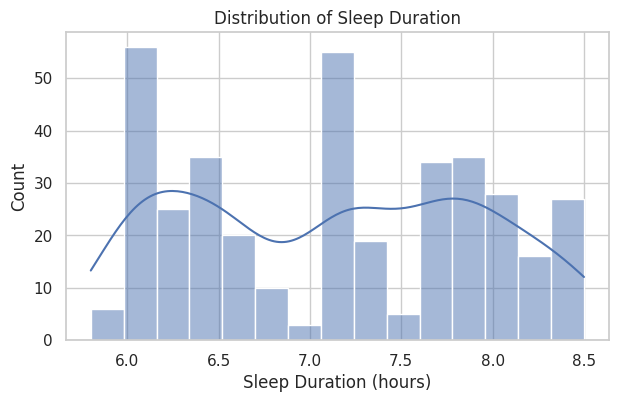

In [18]:

# Visualization 1: Distribution of Sleep Duration
plt.figure(figsize=(7, 4))
sns.histplot(df["Sleep Duration"], bins=15, kde=True)
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Count")
plt.show()

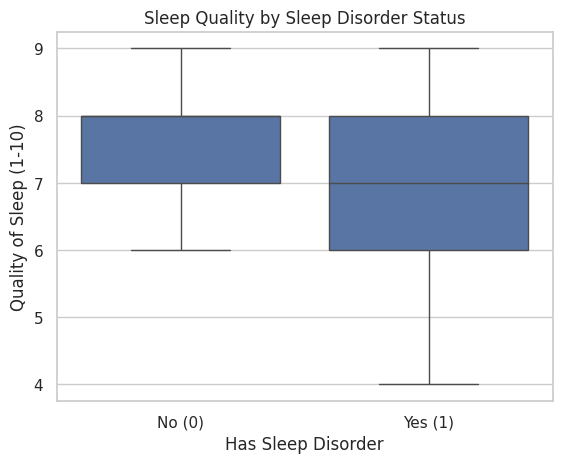

In [19]:
# Sleep quality vs. Has Sleep Disorder
sns.boxplot(x="Has Sleep Disorder", y="Quality of Sleep", data=df)
plt.title("Sleep Quality by Sleep Disorder Status")
plt.xticks([0, 1], ["No (0)", "Yes (1)"])
plt.ylabel("Quality of Sleep (1-10)")
plt.show()